# Olist E-Commerce Sales & Customer Insights Analysis

## Business Problem

An e-commerce company wants to analyze sales performance, customer purchasing behavior, delivery efficiency, and payment trends to improve business decisions.

### Tools Used
- Python
- SQLite
- SQL
- Pandas
- Matplotlib
- Tableau

## Business Problem

E-commerce businesses generate large volumes of transactional data from customers, products, sellers, payments, and deliveries. The objective of this project is to integrate data from multiple relational tables, analyze key business metrics, identify sales trends and customer behavior, evaluate delivery performance, and generate actionable business recommendations through data visualization.

# Table of Contents

1. Business Problem
2. Dataset Overview
3. Import Libraries
4. Database Connection
5. Database Exploration
6. Data Preparation
7. Data Cleaning
8. Feature Engineering
9. Exploratory Data Analysis
10. Business Insights
11. Recommendations
12. Export Dataset


## Dataset Overview

This project uses the **Olist Brazilian E-Commerce Dataset**, a real-world transactional dataset from a Brazilian online marketplace.

The analysis integrates multiple relational tables, including:

- Customers
- Orders
- Order Items
- Products
- Payments
- Reviews
- Sellers

The objective is to analyze sales performance, customer behavior, payment trends, delivery efficiency, and product performance to generate actionable business insights.

### Tools & Technologies

- Python
- SQL (SQLite)
- Pandas
- Matplotlib
- Jupyter Notebook
- Tableau (Dashboard)

### Dataset Size

- 100,000+ Orders
- 99,000+ Customers
- 32,000+ Products
- Multiple relational tables stored in SQLite

## Import Libraries & Connect to Database

In this section, we import the required Python libraries and establish a connection to the SQLite database that contains the Olist e-commerce data.

In [424]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("olist.sqlite")

print("✅ Successfully connected to the Olist database!")

✅ Successfully connected to the Olist database!


## Database Exploration

The first step is to explore the SQLite database to understand the available tables and their structure. This helps identify the datasets required for the analysis.

In [425]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


In [426]:
print(f"Number of tables: {len(tables)}")

Number of tables: 11


In [427]:
for table in tables["name"]:
    print(table)

product_category_name_translation
sellers
customers
geolocation
order_items
order_payments
order_reviews
orders
products
leads_qualified
leads_closed


## Data Understanding

To better understand the structure of the data, we inspect the Orders table, including its columns, data types, and missing values.

In [428]:
orders = pd.read_sql(
    "SELECT * FROM orders;",
    conn
)

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [429]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [430]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [431]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [432]:
orders.duplicated().sum()

np.int64(0)

## Data Integration

The required tables are merged into a single master dataset using SQL LEFT JOIN operations.

The integrated dataset combines customer, order, payment, review, and product information to support end-to-end business analysis.

In [433]:
master_query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,

    c.customer_city,
    c.customer_state,

    oi.product_id,
    oi.seller_id,
    oi.price,
    oi.freight_value,

    p.product_category_name,

    op.payment_type,
    op.payment_installments,
    op.payment_value,

    r.review_score

FROM orders o

LEFT JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN order_items oi
ON o.order_id = oi.order_id

LEFT JOIN products p
ON oi.product_id = p.product_id

LEFT JOIN order_payments op
ON o.order_id = op.order_id

LEFT JOIN order_reviews r
ON o.order_id = r.order_id
"""

master_df = pd.read_sql(master_query, conn)

In [434]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_city,customer_state,product_id,seller_id,price,freight_value,product_category_name,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,credit_card,3.0,179.12,5.0


In [435]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_delivered_customer_date  115722 non-null  object 
 5   customer_city                  119143 non-null  object 
 6   customer_state                 119143 non-null  object 
 7   product_id                     118310 non-null  object 
 8   seller_id                      118310 non-null  object 
 9   price                          118310 non-null  float64
 10  freight_value                  118310 non-null  float64
 11  product_category_name          116601 non-null  object 
 12  payment_type                  

In [436]:
master_df.shape

(119143, 16)

## Data Cleaning

The merged dataset is examined for missing values, duplicate records, and inconsistent data types before analysis.

In [437]:
# Check missing values
master_df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    3421
product_category_name            2542
review_score                      997
product_id                        833
seller_id                         833
price                             833
freight_value                     833
payment_type                        3
payment_installments                3
payment_value                       3
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
customer_city                       0
customer_state                      0
dtype: int64

In [438]:
# Check duplicate rows
master_df.duplicated().sum()

np.int64(11695)

In [439]:
print("Before:", master_df.shape)

master_df = master_df.drop_duplicates()

print("After:", master_df.shape)

Before: (119143, 16)
After: (107448, 16)


In [440]:
master_df["order_purchase_timestamp"] = pd.to_datetime(master_df["order_purchase_timestamp"])
master_df["order_delivered_customer_date"] = pd.to_datetime(master_df["order_delivered_customer_date"])

## Feature Engineering

To support business analysis, new variables were created from the order timestamps.

The engineered features include:

- Year
- Month
- Month Number
- Day
- Weekday
- Quarter
- Delivery Days

In [441]:
master_df["Year"] = master_df["order_purchase_timestamp"].dt.year

master_df["Month"] = master_df["order_purchase_timestamp"].dt.month_name()

master_df["Month_Number"] = master_df["order_purchase_timestamp"].dt.month

master_df["Day"] = master_df["order_purchase_timestamp"].dt.day

master_df["Weekday"] = master_df["order_purchase_timestamp"].dt.day_name()

master_df["Quarter"] = master_df["order_purchase_timestamp"].dt.quarter

In [442]:
master_df["Delivery_Days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

In [443]:
master_df[["order_purchase_timestamp",
           "order_delivered_customer_date",
           "Delivery_Days"]].head()

,order_purchase_timestamp,order_delivered_customer_date,Delivery_Days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
2,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
3,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
4,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0


# Exploratory Data Analysis (EDA)

The cleaned and enriched dataset is analyzed to answer key business questions related to sales performance, customer behavior, delivery efficiency, and payment trends.

## Executive KPI Summary

The following KPIs provide an overview of the overall business performance.

In [444]:
total_revenue = master_df["payment_value"].sum()
total_orders = master_df["order_id"].nunique()
total_customers = master_df["customer_id"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue: $", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value: $", round(average_order_value, 2))
print("Average Review Score:", round(master_df["review_score"].mean(), 2))
print("Average Delivery Days:", round(master_df["Delivery_Days"].mean(), 2))

Total Revenue: $ 17009898.15
Total Orders: 99441
Total Customers: 99441
Average Order Value: $ 171.06
Average Review Score: 4.06
Average Delivery Days: 12.05


In [445]:
import matplotlib.pyplot as plt

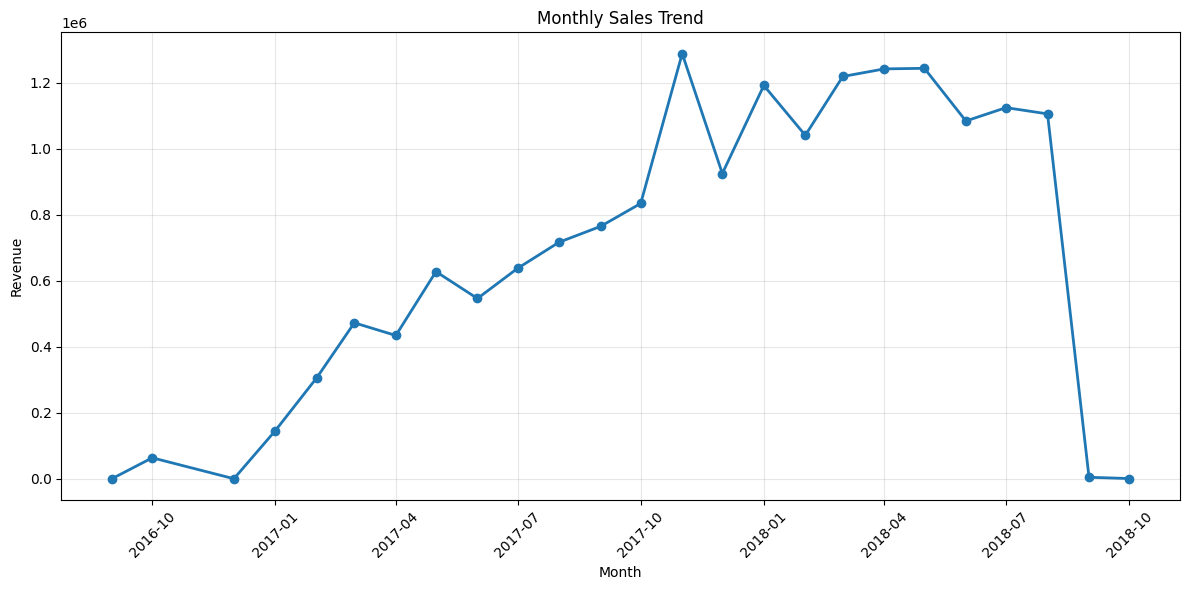

In [446]:
monthly_sales = (
    master_df
    .groupby(["Year", "Month_Number"])["payment_value"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month_Number"].astype(str)
)

monthly_sales = monthly_sales.sort_values("Date")

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["payment_value"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

Revenue varies over time, indicating seasonal changes in customer purchasing behavior.

### Business Recommendation

Use high-demand periods for inventory planning and marketing campaigns while identifying reasons for slower months.

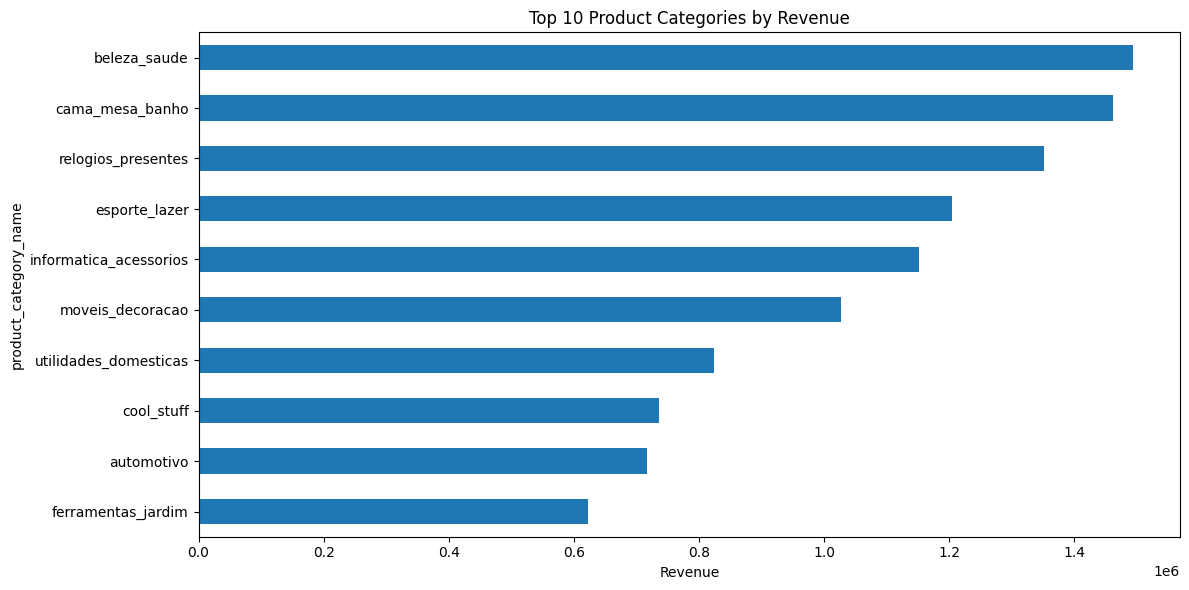

In [447]:
category_sales = (
    master_df
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

category_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

### Business Insight

A small number of product categories contribute a large share of total revenue.

### Business Recommendation

Prioritize inventory and promotional spending for high-performing categories while evaluating opportunities to improve lower-performing ones.

## Payment Method Distribution

### Business Question

Which payment methods are most commonly used by customers?

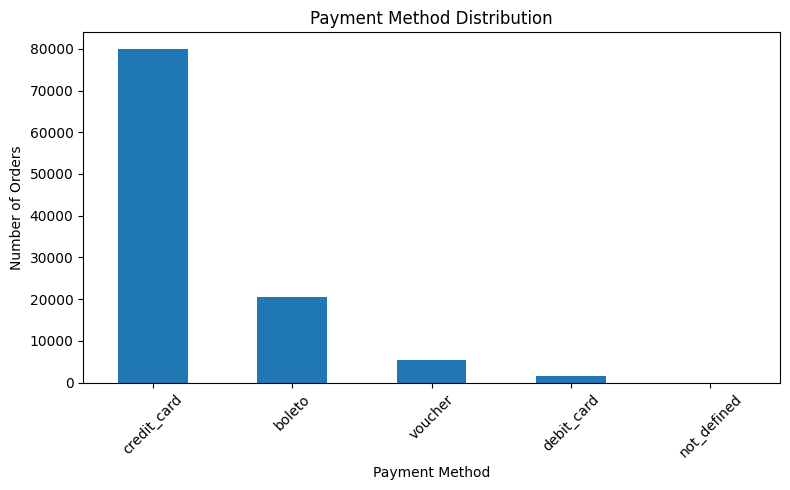

In [448]:
payment_distribution = (
    master_df["payment_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

payment_distribution.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Insight

The distribution highlights the payment methods customers use most frequently, helping identify customer preferences during checkout.

### Business Recommendation

Ensure the most popular payment method provides a fast and reliable checkout experience while promoting alternative payment options where appropriate.   

## Customer Review Score Distribution

### Business Question

How satisfied are customers with their purchases based on review scores?

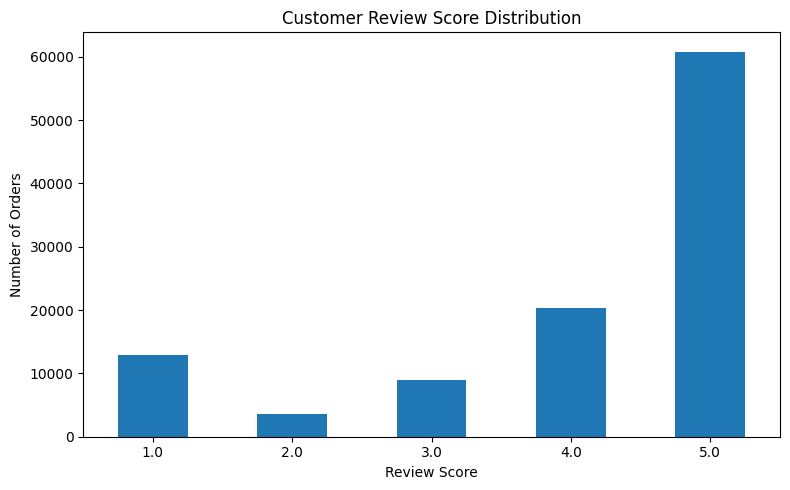

In [449]:
review_distribution = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

review_distribution.plot(kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Business Insight

The review score distribution provides an overview of customer satisfaction. A concentration of higher review scores indicates positive customer experiences, while lower scores may highlight issues related to delivery, product quality, or seller performance.

### Business Recommendation

Analyze orders with low review scores alongside delivery times and seller information to identify opportunities for improving customer satisfaction.

## Delivery Time Analysis

### Business Question

How long does it typically take for customers to receive their orders?

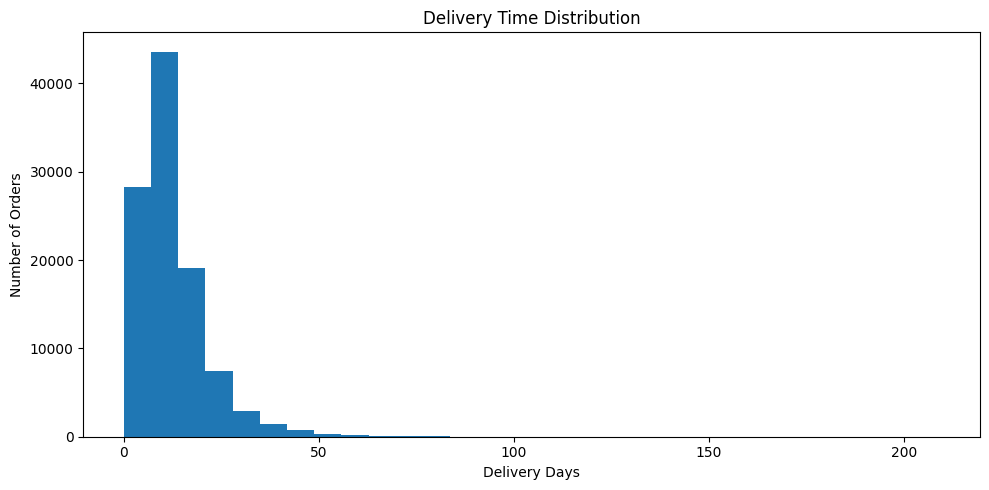

In [450]:
delivery = master_df["Delivery_Days"].dropna()

plt.figure(figsize=(10,5))

plt.hist(delivery, bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.show()

### Business Insight

Most deliveries are completed within a relatively short time frame, although a small number of orders experience significantly longer delivery times.

### Business Recommendation

Identify orders with unusually long delivery times and analyze the associated sellers, products, and locations to improve logistics performance.

## Geographic Revenue Analysis

### Business Question

Which customer states generate the highest revenue?

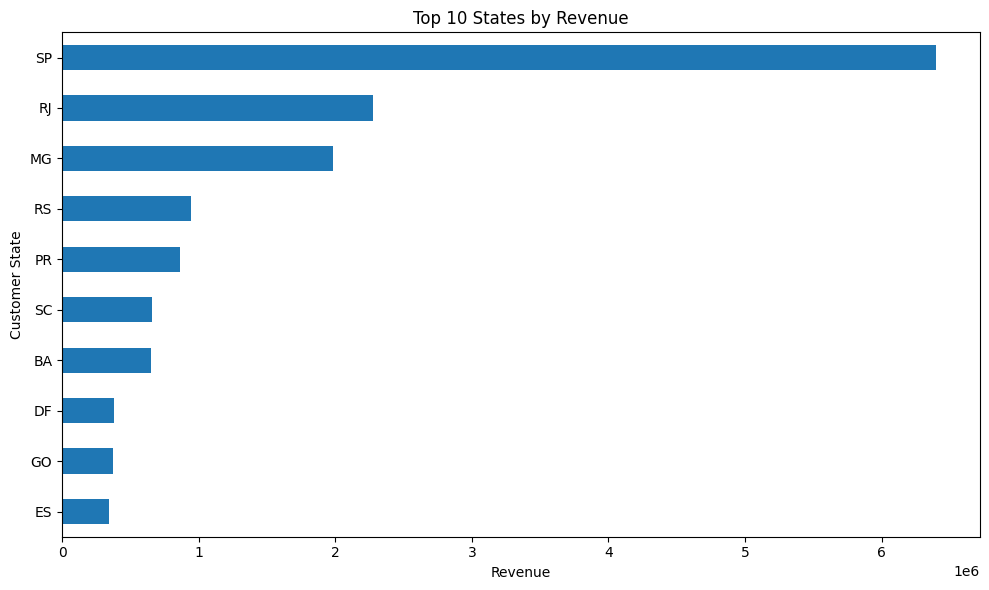

In [451]:
state_sales = (
    master_df
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

state_sales.sort_values().plot(kind="barh")

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer State")
plt.tight_layout()

plt.show()

### Business Insight

A small number of states contribute a significant share of total revenue, highlighting key regional markets.

### Business Recommendation

Prioritize marketing campaigns, inventory allocation, and customer retention efforts in the highest-performing states while identifying growth opportunities in lower-performing regions.

## Order Status Distribution

### Business Question

What proportion of orders are delivered, canceled, shipped, or in other statuses?

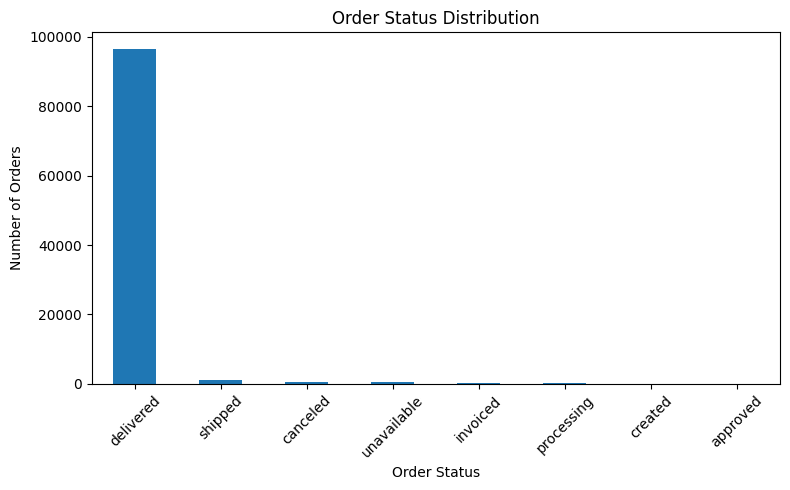

In [452]:
status = (
    master_df
    .drop_duplicates(subset="order_id")["order_status"]
    .value_counts()
)

plt.figure(figsize=(8,5))

status.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Insight

Most orders are successfully delivered, while only a small percentage remain canceled or in other processing stages.

### Business Recommendation

Continue monitoring canceled and delayed orders to identify operational bottlenecks and improve fulfillment efficiency.

## Top Sellers by Revenue

### Business Question

Which sellers contribute the most revenue?

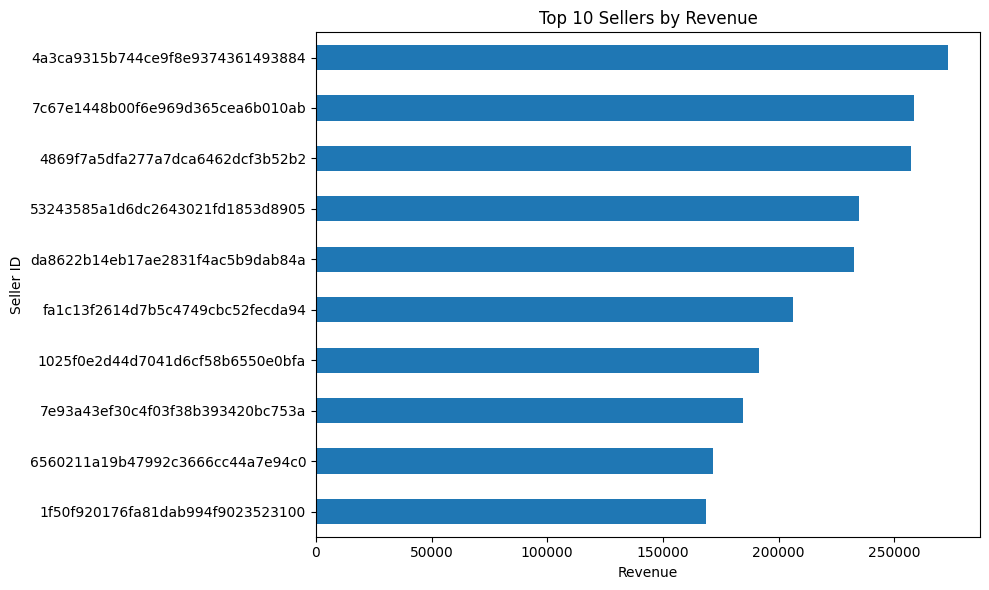

In [453]:
seller_sales = (
    master_df
    .groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

seller_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.tight_layout()

plt.show()

### Business Insight

Revenue is concentrated among a relatively small number of sellers, indicating that top-performing sellers play a significant role in overall business performance.

### Conclusion

This analysis combined multiple e-commerce datasets to evaluate sales performance, customer satisfaction, payment preferences, geographic demand, delivery efficiency, and seller performance. The findings highlight opportunities to improve operational efficiency, strengthen customer experience, and support data-driven business decisions.

### Business Recommendation

Strengthen relationships with high-performing sellers while providing support and performance feedback to lower-performing sellers.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Prioritize inventory planning for high-performing product categories to avoid stock shortages.

2. Improve delivery performance by identifying logistics bottlenecks and reducing long delivery times.

3. Investigate low customer review scores to address recurring service or product issues.

4. Focus marketing efforts on the highest-revenue customer states while exploring growth opportunities in underperforming regions.

5. Maintain strong relationships with top-performing sellers and develop improvement plans for lower-performing sellers.

6. Optimize the checkout experience for the most frequently used payment methods while promoting alternative payment options.

## Export Clean Dataset

The cleaned and feature-engineered dataset is exported for use in Tableau and future business intelligence reporting.

In [454]:
master_df.to_csv("olist_clean.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
